In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the dataset into python environment

In [2]:
data = pd.read_csv(r"C:\Users\symbi\Downloads\titanic_dataset (1).csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Make ‘PassengerId’ as the index column

In [4]:
data.set_index("PassengerId", inplace=True)

In [5]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check the basic details of the dataset

In [6]:
data.shape

(891, 11)

In [7]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [9]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

## Define X and y

In [12]:
y = data["Survived"]

In [13]:
x = data.drop("Survived", axis=1)

In [15]:
x.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
y.head()

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64

In [17]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [20]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 10)
X_test: (179, 10)
y_train: (712,)
y_test: (179,)


## Handle Missing Values

In [21]:
print("Training Data:")
print(x_train.isnull().sum())

print("\nTesting Data:")
print(x_test.isnull().sum())

Training Data:
Pclass        0
Name          0
Sex           0
Age         137
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       552
Embarked      2
dtype: int64

Testing Data:
Pclass        0
Name          0
Sex           0
Age          40
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       135
Embarked      0
dtype: int64


In [22]:
age_median = x_train["Age"].median()

age_median

28.5

In [23]:
x_train["Age"] = x_train["Age"].fillna(age_median)
x_test["Age"] = x_test["Age"].fillna(age_median)

In [24]:
embarked_mode = x_train["Embarked"].mode()[0]

embarked_mode

'S'

In [25]:
x_train["Embarked"] = x_train["Embarked"].fillna(embarked_mode)
x_test["Embarked"] = x_test["Embarked"].fillna(embarked_mode)

In [26]:
x_train["Cabin"] = x_train["Cabin"].fillna("Unknown")
x_test["Cabin"] = x_test["Cabin"].fillna("Unknown")

In [27]:
print("Training Missing Values:")
print(x_train.isnull().sum())

print("\nTesting Missing Values:")
print(x_test.isnull().sum())

Training Missing Values:
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

Testing Missing Values:
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64


## Check and handle outliers in at least 3 columns in the dataset

### Age

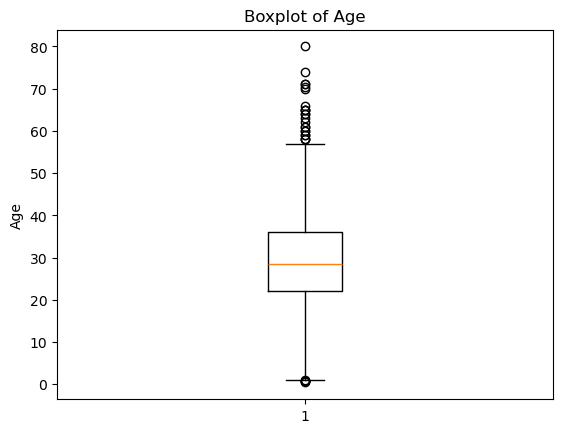

In [28]:
plt.boxplot(x_train["Age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

### Fare

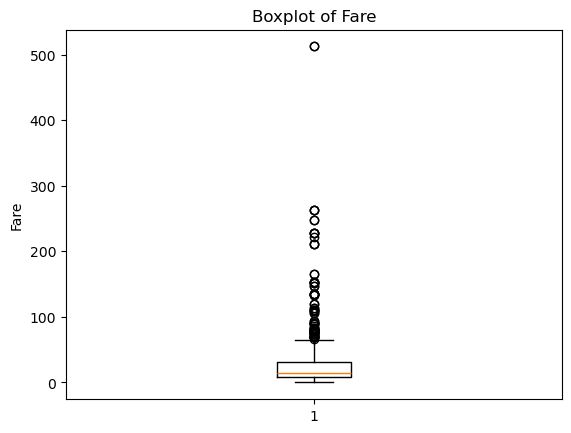

In [29]:
plt.boxplot(x_train["Fare"])
plt.title("Boxplot of Fare")
plt.ylabel("Fare")
plt.show()

### SibSp

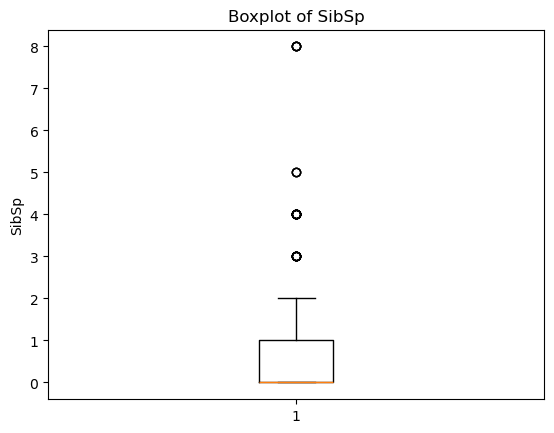

In [30]:
plt.boxplot(x_train["SibSp"])
plt.title("Boxplot of SibSp")
plt.ylabel("SibSp")
plt.show()

In [31]:
Q1 = x_train["Age"].quantile(0.25)
Q3 = x_train["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 22.0
Q3: 36.0
IQR: 14.0
Lower Limit: 1.0
Upper Limit: 57.0


In [32]:
age_outliers = x_train[
    (x_train["Age"] < lower_limit) |
    (x_train["Age"] > upper_limit)
]

print("Number of Age Outliers:", len(age_outliers))

Number of Age Outliers: 29


In [33]:
Q1 = x_train["Fare"].quantile(0.25)
Q3 = x_train["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Limit: -26.7605
Upper Limit: 65.6563


In [34]:
fare_outliers = x_train[
    (x_train["Fare"] < lower_limit) |
    (x_train["Fare"] > upper_limit)
]

print("Number of Fare Outliers:", len(fare_outliers))

Number of Fare Outliers: 91


In [35]:
Q1 = x_train["SibSp"].quantile(0.25)
Q3 = x_train["SibSp"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Limit: -1.5
Upper Limit: 2.5


In [36]:
sibsp_outliers = x_train[
    (x_train["SibSp"] < lower_limit) |
    (x_train["SibSp"] > upper_limit)
]

print("Number of SibSp Outliers:", len(sibsp_outliers))

Number of SibSp Outliers: 33


In [37]:
columns = ["Age", "Fare", "SibSp"]

for column in columns:
    
    Q1 = x_train[column].quantile(0.25)
    Q3 = x_train[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    x_train[column] = x_train[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )
    
    x_test[column] = x_test[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

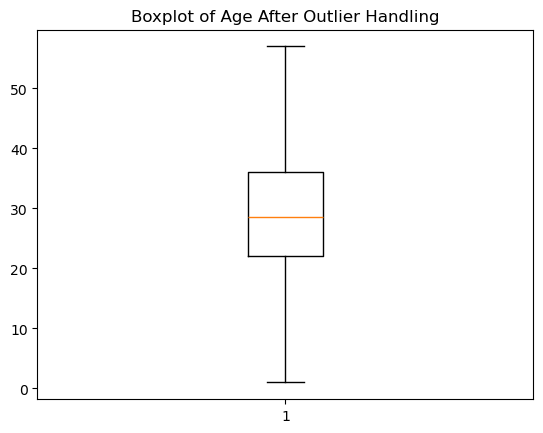

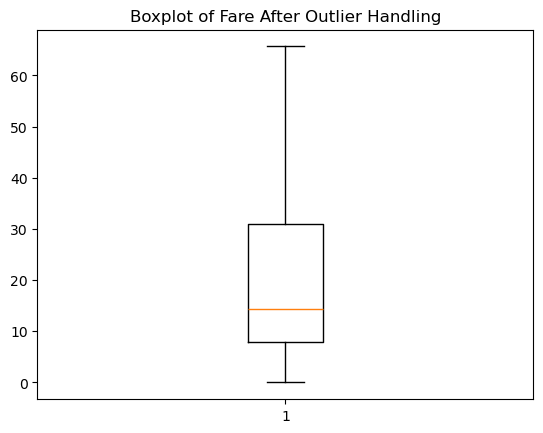

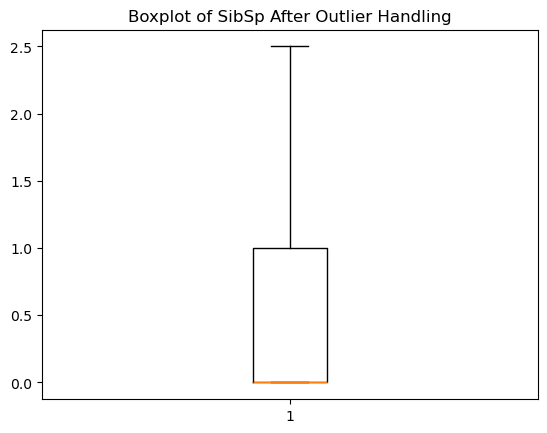

In [38]:
for column in columns:
    plt.boxplot(x_train[column])
    plt.title("Boxplot of " + column + " After Outlier Handling")
    plt.show()

## Feature selection and categorical encoding

In [39]:
x_train.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [40]:
x_train = x_train.drop(["Name", "Ticket", "Cabin"], axis=1)
x_test = x_test.drop(["Name", "Ticket", "Cabin"], axis=1)

In [41]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
693,3,male,28.5,0.0,0,56.4958,S
482,2,male,28.5,0.0,0,0.0000,S
528,1,male,28.5,0.0,0,65.6563,S
856,3,female,18.0,0.0,1,9.3500,S
802,2,female,31.0,1.0,1,26.2500,S


In [42]:
x_train.drop(["Embarked"], axis=1, inplace=True)
x_test.drop(["Embarked"], axis=1, inplace=True)

In [43]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,,,,,,
693,3,male,28.5,0.0,0,56.4958
482,2,male,28.5,0.0,0,0.0000
528,1,male,28.5,0.0,0,65.6563
856,3,female,18.0,0.0,1,9.3500
802,2,female,31.0,1.0,1,26.2500


In [44]:
x_train["Sex"] = x_train["Sex"].map({
    "male": 0,
    "female": 1
})

x_test["Sex"] = x_test["Sex"].map({
    "male": 0,
    "female": 1
})

In [45]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,,,,,,
693,3,0,28.5,0.0,0,56.4958
482,2,0,28.5,0.0,0,0.0000
528,1,0,28.5,0.0,0,65.6563
856,3,1,18.0,0.0,1,9.3500
802,2,1,31.0,1.0,1,26.2500


In [46]:
x_train.dtypes

Pclass      int64
Sex         int64
Age       float64
SibSp     float64
Parch       int64
Fare      float64
dtype: object

## Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
scaler = StandardScaler()

In [49]:
x_train_scaled = scaler.fit_transform(x_train)

In [50]:
x_test_scaled = scaler.transform(x_test)

In [51]:
x_train_scaled[:5]

array([[ 0.82956755, -0.74242727, -0.06586279, -0.5886606 , -0.46618317,
         1.58731267],
       [-0.37094484, -0.74242727, -0.06586279, -0.5886606 , -0.46618317,
        -1.16878026],
       [-1.57145722, -0.74242727, -0.06586279, -0.5886606 , -0.46618317,
         2.0341988 ],
       [ 0.82956755,  1.34693328, -0.9148114 , -0.5886606 ,  0.72778236,
        -0.71264956],
       [-0.37094484,  1.34693328,  0.13626784,  0.86411703,  0.72778236,
         0.11180059]])

## Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
log_model = LogisticRegression()

log_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_pred_log = log_model.predict(x_test_scaled)

In [55]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7988826815642458
Precision: 0.7538461538461538
Recall: 0.7101449275362319
F1 Score: 0.7313432835820896


In [57]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Confusion Matrix:
[[94 16]
 [20 49]]


In [58]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## K-Nearest Neighbors (KNN)

In [59]:
from sklearn.neighbors import KNeighborsClassifier

In [60]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [61]:
knn_model.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
y_pred_knn = knn_model.predict(x_test_scaled)

In [63]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

Accuracy: 0.776536312849162
Precision: 0.7301587301587301
Recall: 0.6666666666666666
F1 Score: 0.696969696969697


In [64]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Confusion Matrix:
[[93 17]
 [23 46]]


## Support Vector Machine (SVM)

In [66]:
from sklearn.svm import SVC

In [67]:
svm_model = SVC()

In [68]:
svm_model.fit(x_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [69]:
y_pred_svm = svm_model.predict(x_test_scaled)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.7988826815642458
Precision: 0.8113207547169812
Recall: 0.6231884057971014
F1 Score: 0.7049180327868853


In [71]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Confusion Matrix:
[[100  10]
 [ 26  43]]


## Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [73]:
dt_model = DecisionTreeClassifier(random_state=42)

In [74]:
dt_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
y_pred_dt = dt_model.predict(x_test)

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.7932960893854749
Precision: 0.7352941176470589
Recall: 0.7246376811594203
F1 Score: 0.7299270072992701


In [77]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Confusion Matrix:
[[92 18]
 [19 50]]


## Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [80]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
y_pred_rf = rf_model.predict(x_test)

In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8212290502793296
Precision: 0.7936507936507936
Recall: 0.7246376811594203
F1 Score: 0.7575757575757576


In [83]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix:
[[97 13]
 [19 50]]


## Naive Bayes

In [84]:
from sklearn.naive_bayes import GaussianNB

In [85]:
nb_model = GaussianNB()

In [86]:
nb_model.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [87]:
y_pred_nb = nb_model.predict(x_test)

In [88]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

Accuracy: 0.7541899441340782
Precision: 0.6623376623376623
Recall: 0.7391304347826086
F1 Score: 0.6986301369863014


In [89]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Confusion Matrix:
[[84 26]
 [18 51]]


## Model Comparison

In [90]:
results = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb)
    ]
}

In [91]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.798883,0.753846,0.710145,0.731343
1,KNN,0.776536,0.730159,0.666667,0.696970
2,SVM,0.798883,0.811321,0.623188,0.704918
3,Decision Tree,0.793296,0.735294,0.724638,0.729927
4,Random Forest,0.821229,0.793651,0.724638,0.757576
5,Naive Bayes,0.754190,0.662338,0.739130,0.698630


In [92]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.821229,0.793651,0.724638,0.757576
0,Logistic Regression,0.798883,0.753846,0.710145,0.731343
2,SVM,0.798883,0.811321,0.623188,0.704918
3,Decision Tree,0.793296,0.735294,0.724638,0.729927
1,KNN,0.776536,0.730159,0.666667,0.696970
5,Naive Bayes,0.754190,0.662338,0.739130,0.698630


## Conclusion

The Titanic dataset was preprocessed by handling missing values, treating outliers in **Age, Fare, and SibSp**, removing unnecessary features, encoding categorical data, and applying feature scaling where required.

Six classification models were trained and evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- Naive Bayes

Among the tested models, **Random Forest achieved the highest accuracy of approximately 82.12% and an F1 score of 75.76%**.

Therefore, based on this train-test split, **Random Forest showed the best overall performance among the models tested**.